In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
def build_azimuth_bin_map(dataset, bin_width=10):
    # --- Step 1: gather azimuth values per class ---
    class_azims = defaultdict(list)
    for path, label in dataset.samples:
        az = parse_metadata(path)['azim']
        if az is not None:
            class_azims[label].append(az)

    # --- Step 2: compute bin ranges per class ---
    class_bin_info = {}
    for label, azims in class_azims.items():
        az_min = min(azims)
        az_max = max(azims)
        bin_start = (az_min // bin_width) * bin_width
        bin_end   = (az_max // bin_width) * bin_width
        bins = list(range(bin_start, bin_end + bin_width, bin_width))
        class_bin_info[label] = {
            'min'   : az_min,
            'max'   : az_max,
            'bins'  : bins,
            'n_bins': len(bins),
        }

    # --- Step 3: compute global offset per class (last class first) ---
    sorted_classes = sorted(class_bin_info.keys(), reverse=False)
    offset = {}
    cumulative = 0
    for label in sorted_classes:
        offset[label] = cumulative
        cumulative += class_bin_info[label]['n_bins']
    total_bins = cumulative

    # --- Step 4: assign each sample a global bin index ---
    sample_to_bin_idx = {}
    for sample_idx, (path, label) in enumerate(dataset.samples):
        az = parse_metadata(path)['azim']
        if az is None:
            continue
        info = class_bin_info[label]
        bin_start_for_az = (az // bin_width) * bin_width
        local_bin = (bin_start_for_az - info['bins'][0]) // bin_width
        sample_to_bin_idx[sample_idx] = offset[label] + local_bin

    # --- Step 5: build new class name list indexed by new label ---
    new_classes = [None] * total_bins
    for label in sorted_classes:
        info = class_bin_info[label]
        vehicle = dataset.classes[label]
        for local_bin, bin_lower in enumerate(info['bins']):
            new_label = offset[label] + local_bin
            new_classes[new_label] = f"{vehicle}_az{bin_lower}"

    
    new_to_old_classes = {}
    for label in sorted_classes:
        info = class_bin_info[label]
        for local_bin in range(info['n_bins']):
            new_label = offset[label] + local_bin
            new_to_old_classes[new_label] = label

    return sample_to_bin_idx, class_bin_info, total_bins, new_classes, new_to_old_classes


def print_bin_summary(class_bin_info, dataset, bin_width=10):
    print(f"{'Label':<6} {'Class':<20} {'Az range':<14} {'N_bins'}")
    print("-" * 55)
    for label in sorted(class_bin_info):
        info = class_bin_info[label]
        class_name = dataset.classes[label]
        az_range = f"{info['min']} – {info['max']}"
        print(f"{label:<6} {class_name:<20} {az_range:<14} {info['n_bins']}")
    k = len(class_bin_info)
    total = sum(v['n_bins'] for v in class_bin_info.values())
    print("-" * 55)
    print(f"k={k} classes, total bins = {total}  (= Σ N_i)")


class AzimuthBinnedDataset(Dataset):
    def __init__(self, dataset, sample_to_bin_idx, new_classes):
        self.dataset = dataset
        self.sample_to_bin_idx = sample_to_bin_idx
        self.classes = new_classes
        self.valid_indices = [i for i in range(len(dataset)) if i in sample_to_bin_idx]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        image, _ = self.dataset[original_idx]
        new_label = self.sample_to_bin_idx[original_idx]
        return image, new_label

    @property
    def samples(self):
        return [(self.dataset.samples[i][0], self.sample_to_bin_idx[i]) for i in self.valid_indices]

In [6]:
no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})

s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
print_bin_summary(b, no_aug_synth_ds_14_15_16)

new_no_aug_synth_ds_14_15_16 = AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [7]:
no_aug_synth_ds_17 = filter_by_elev(no_aug_synth_ds, {17})

s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(no_aug_synth_ds_17, bin_width=10)
print_bin_summary(b, no_aug_synth_ds_17)

new_no_aug_synth_ds_17 = AzimuthBinnedDataset(no_aug_synth_ds_17, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 12 – 79        7
2      btr70                11 – 79        7
3      m1                   12 – 78        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 77        7
8      t72                  11 – 78        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [8]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
print_bin_summary(b, meas_ds_17)

new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 12 – 79        7
2      btr70                11 – 79        7
3      m1                   12 – 78        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 77        7
8      t72                  11 – 78        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [9]:
train_ds = new_no_aug_synth_ds_14_15_16
valid_ds = new_no_aug_synth_ds_17
test_ds  = new_meas_ds_17

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [15]:
len(train_ds), len(valid_ds), len(test_ds)

(806, 539, 539)

In [16]:
len(train_ds.classes), len(valid_ds.classes), len(test_ds.classes)

(70, 70, 70)

In [12]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.classes))
    )

    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16.pth"))

    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 3.6081701922 Acc: 0.1662531017
val Loss: 4.9185071275 Acc: 0.0445269017
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 1.8014769829 Acc: 0.5322580645
val Loss: 1.9546457660 Acc: 0.4823747681
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.8563573760 Acc: 0.7940446650
val Loss: 1.3430797530 Acc: 0.6549165121
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.4249991584 Acc: 0.9255583127
val Loss: 1.0304396701 Acc: 0.7792207792
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.2475020442 Acc: 0.9578163772
val Loss: 0.6624160559 Acc: 0.8051948052
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.2266718711 Acc: 0.9553349876
val Loss: 0.9796322241 Acc: 0.7532467532
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.1655866255 Acc: 0.9677419355
val Loss: 0.6386678679 Acc: 0.8144712430
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0998727409 Acc: 0.9801488834
val Loss: 0.4921293829 Acc: 0.8738404453
Epoch 7 LR: 0.0002988184
Epoch 8
train

In [16]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.classes))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc*100:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0 with seed 10
Test Accuracy: 42.3006
Evaluating Run 1 with seed 42
Test Accuracy: 50.2783
Evaluating Run 2 with seed 100
Test Accuracy: 44.8980
Evaluating Run 3 with seed 123
Test Accuracy: 45.2690
Evaluating Run 4 with seed 666
Test Accuracy: 44.1558
Evaluating Run 5 with seed 777
Test Accuracy: 44.7124
Evaluating Run 6 with seed 849
Test Accuracy: 44.1558
Evaluating Run 7 with seed 1000
Test Accuracy: 44.8980
Evaluating Run 8 with seed 1111
Test Accuracy: 42.1150
Evaluating Run 9 with seed 1234
Test Accuracy: 49.1651


In [14]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 42.1150
Max: 50.2783
Avg, Std: 45.1948, 2.4908


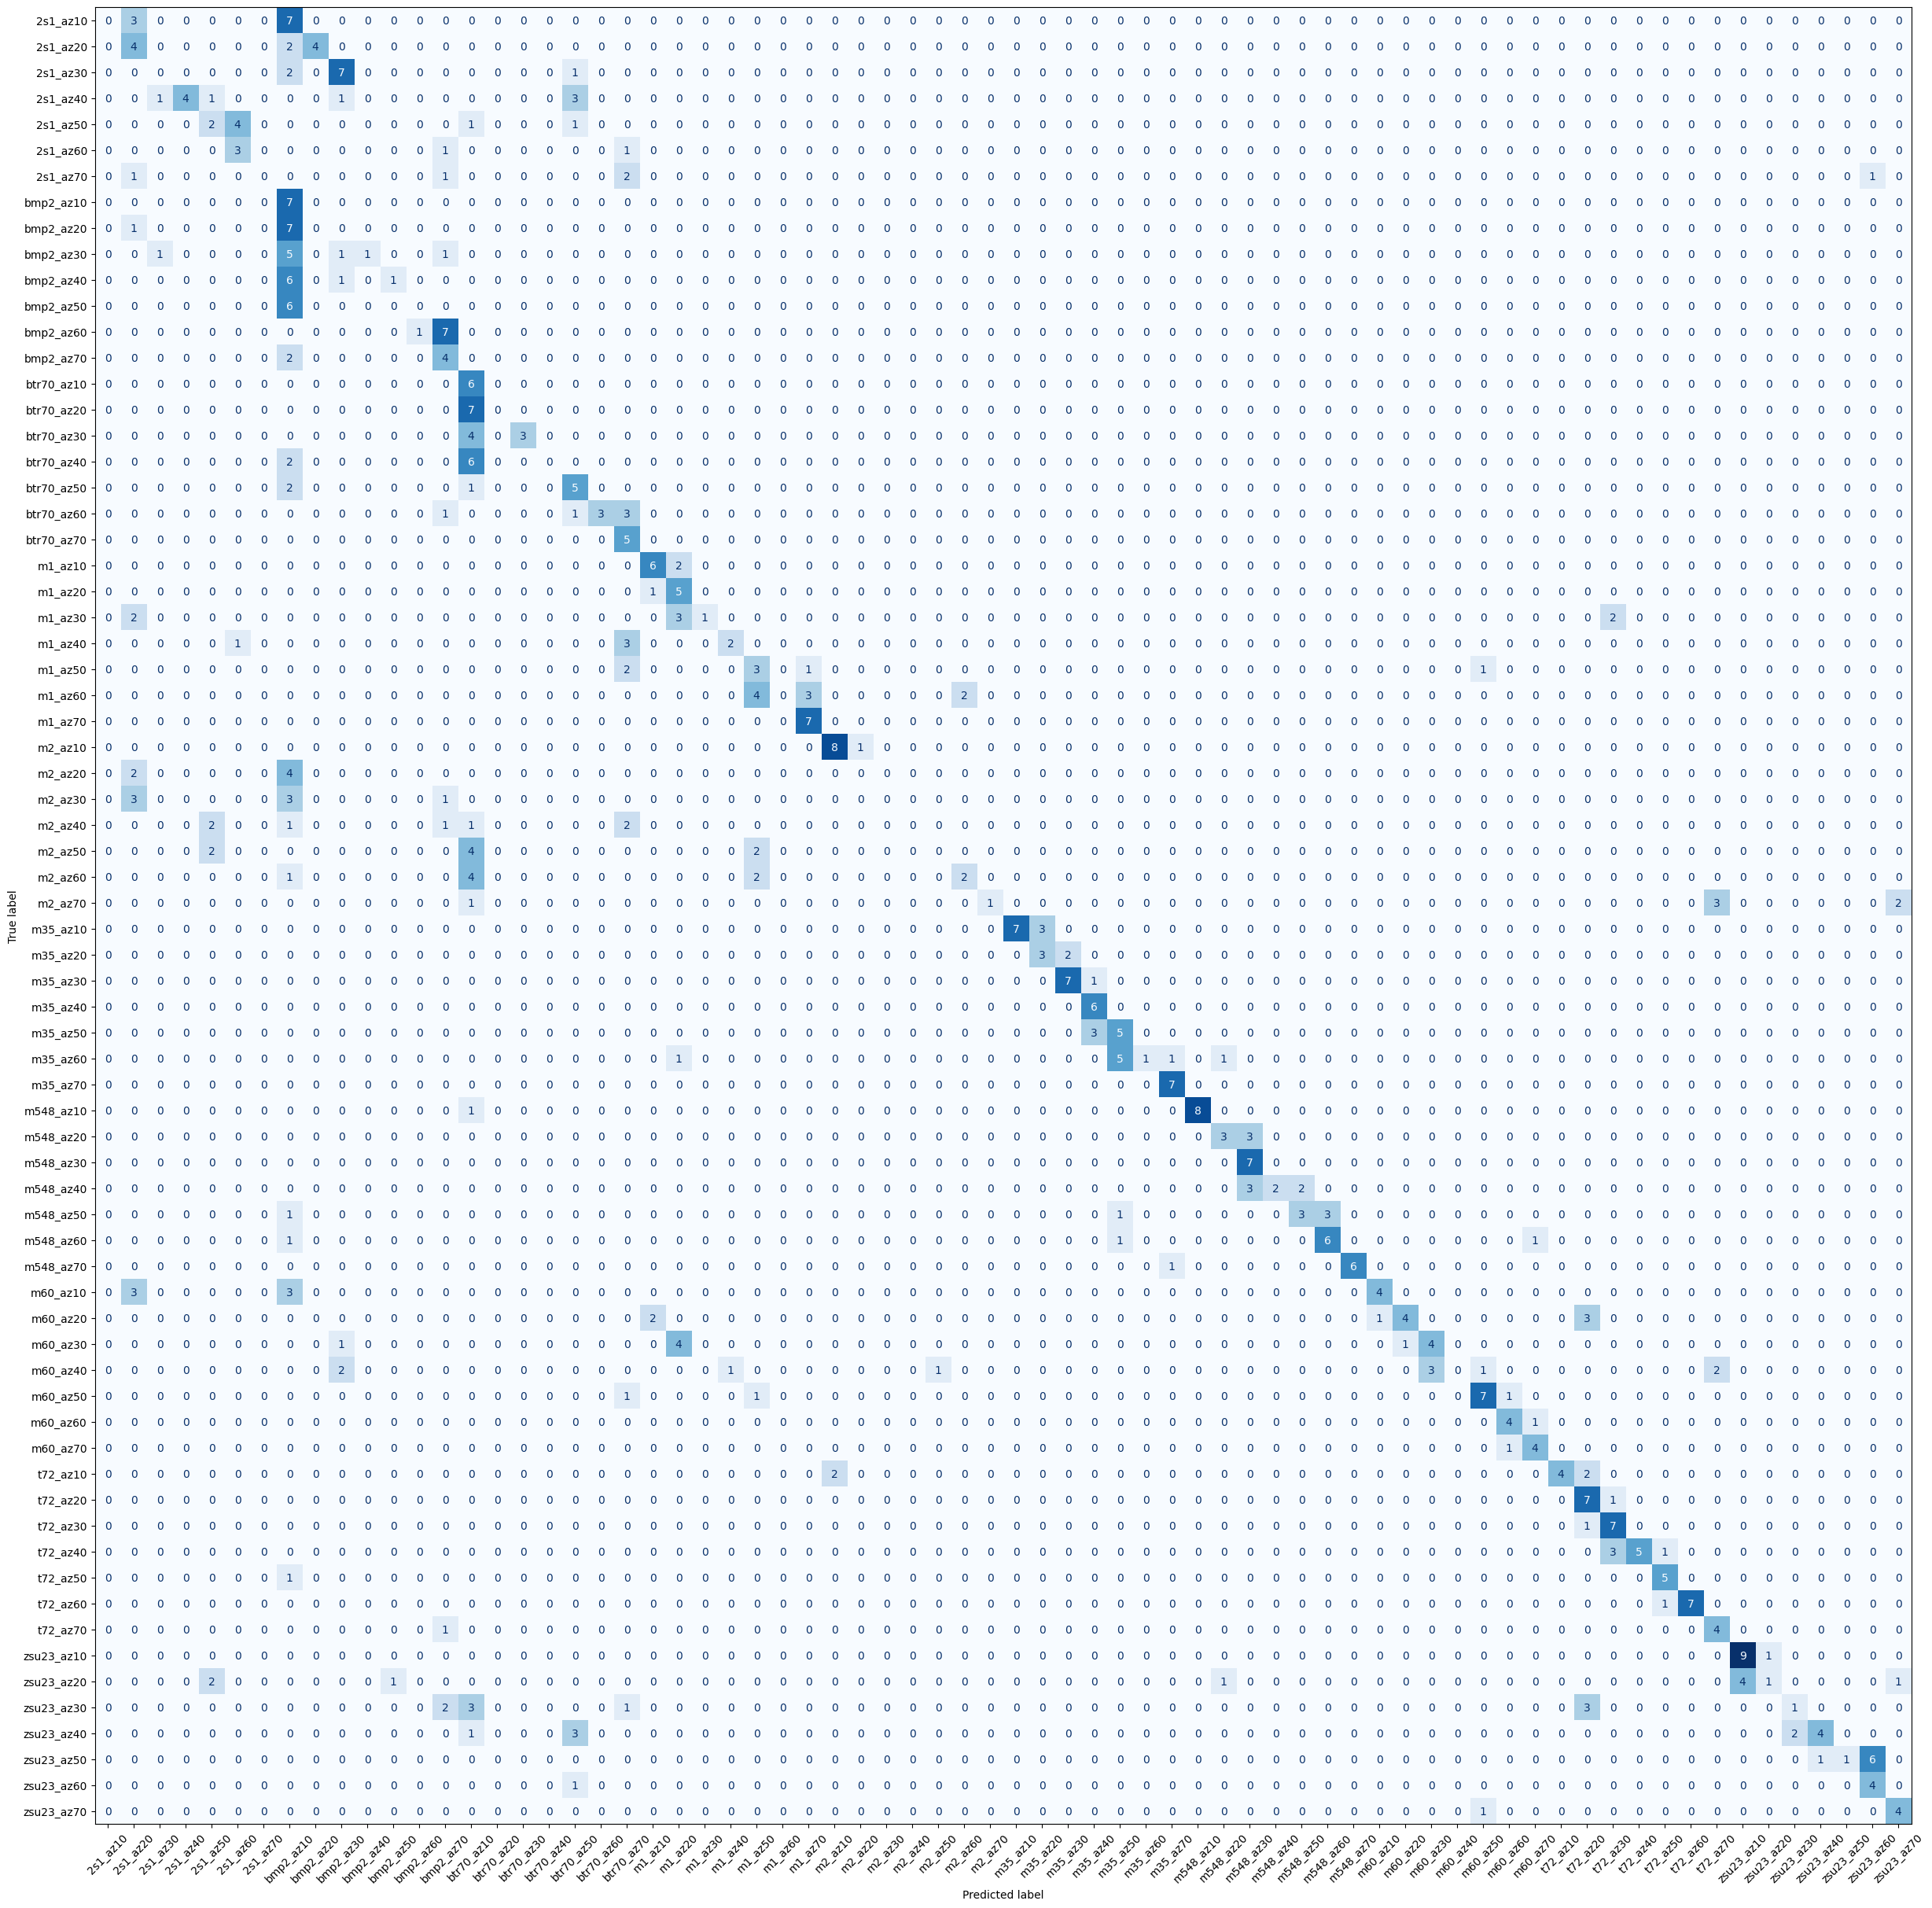

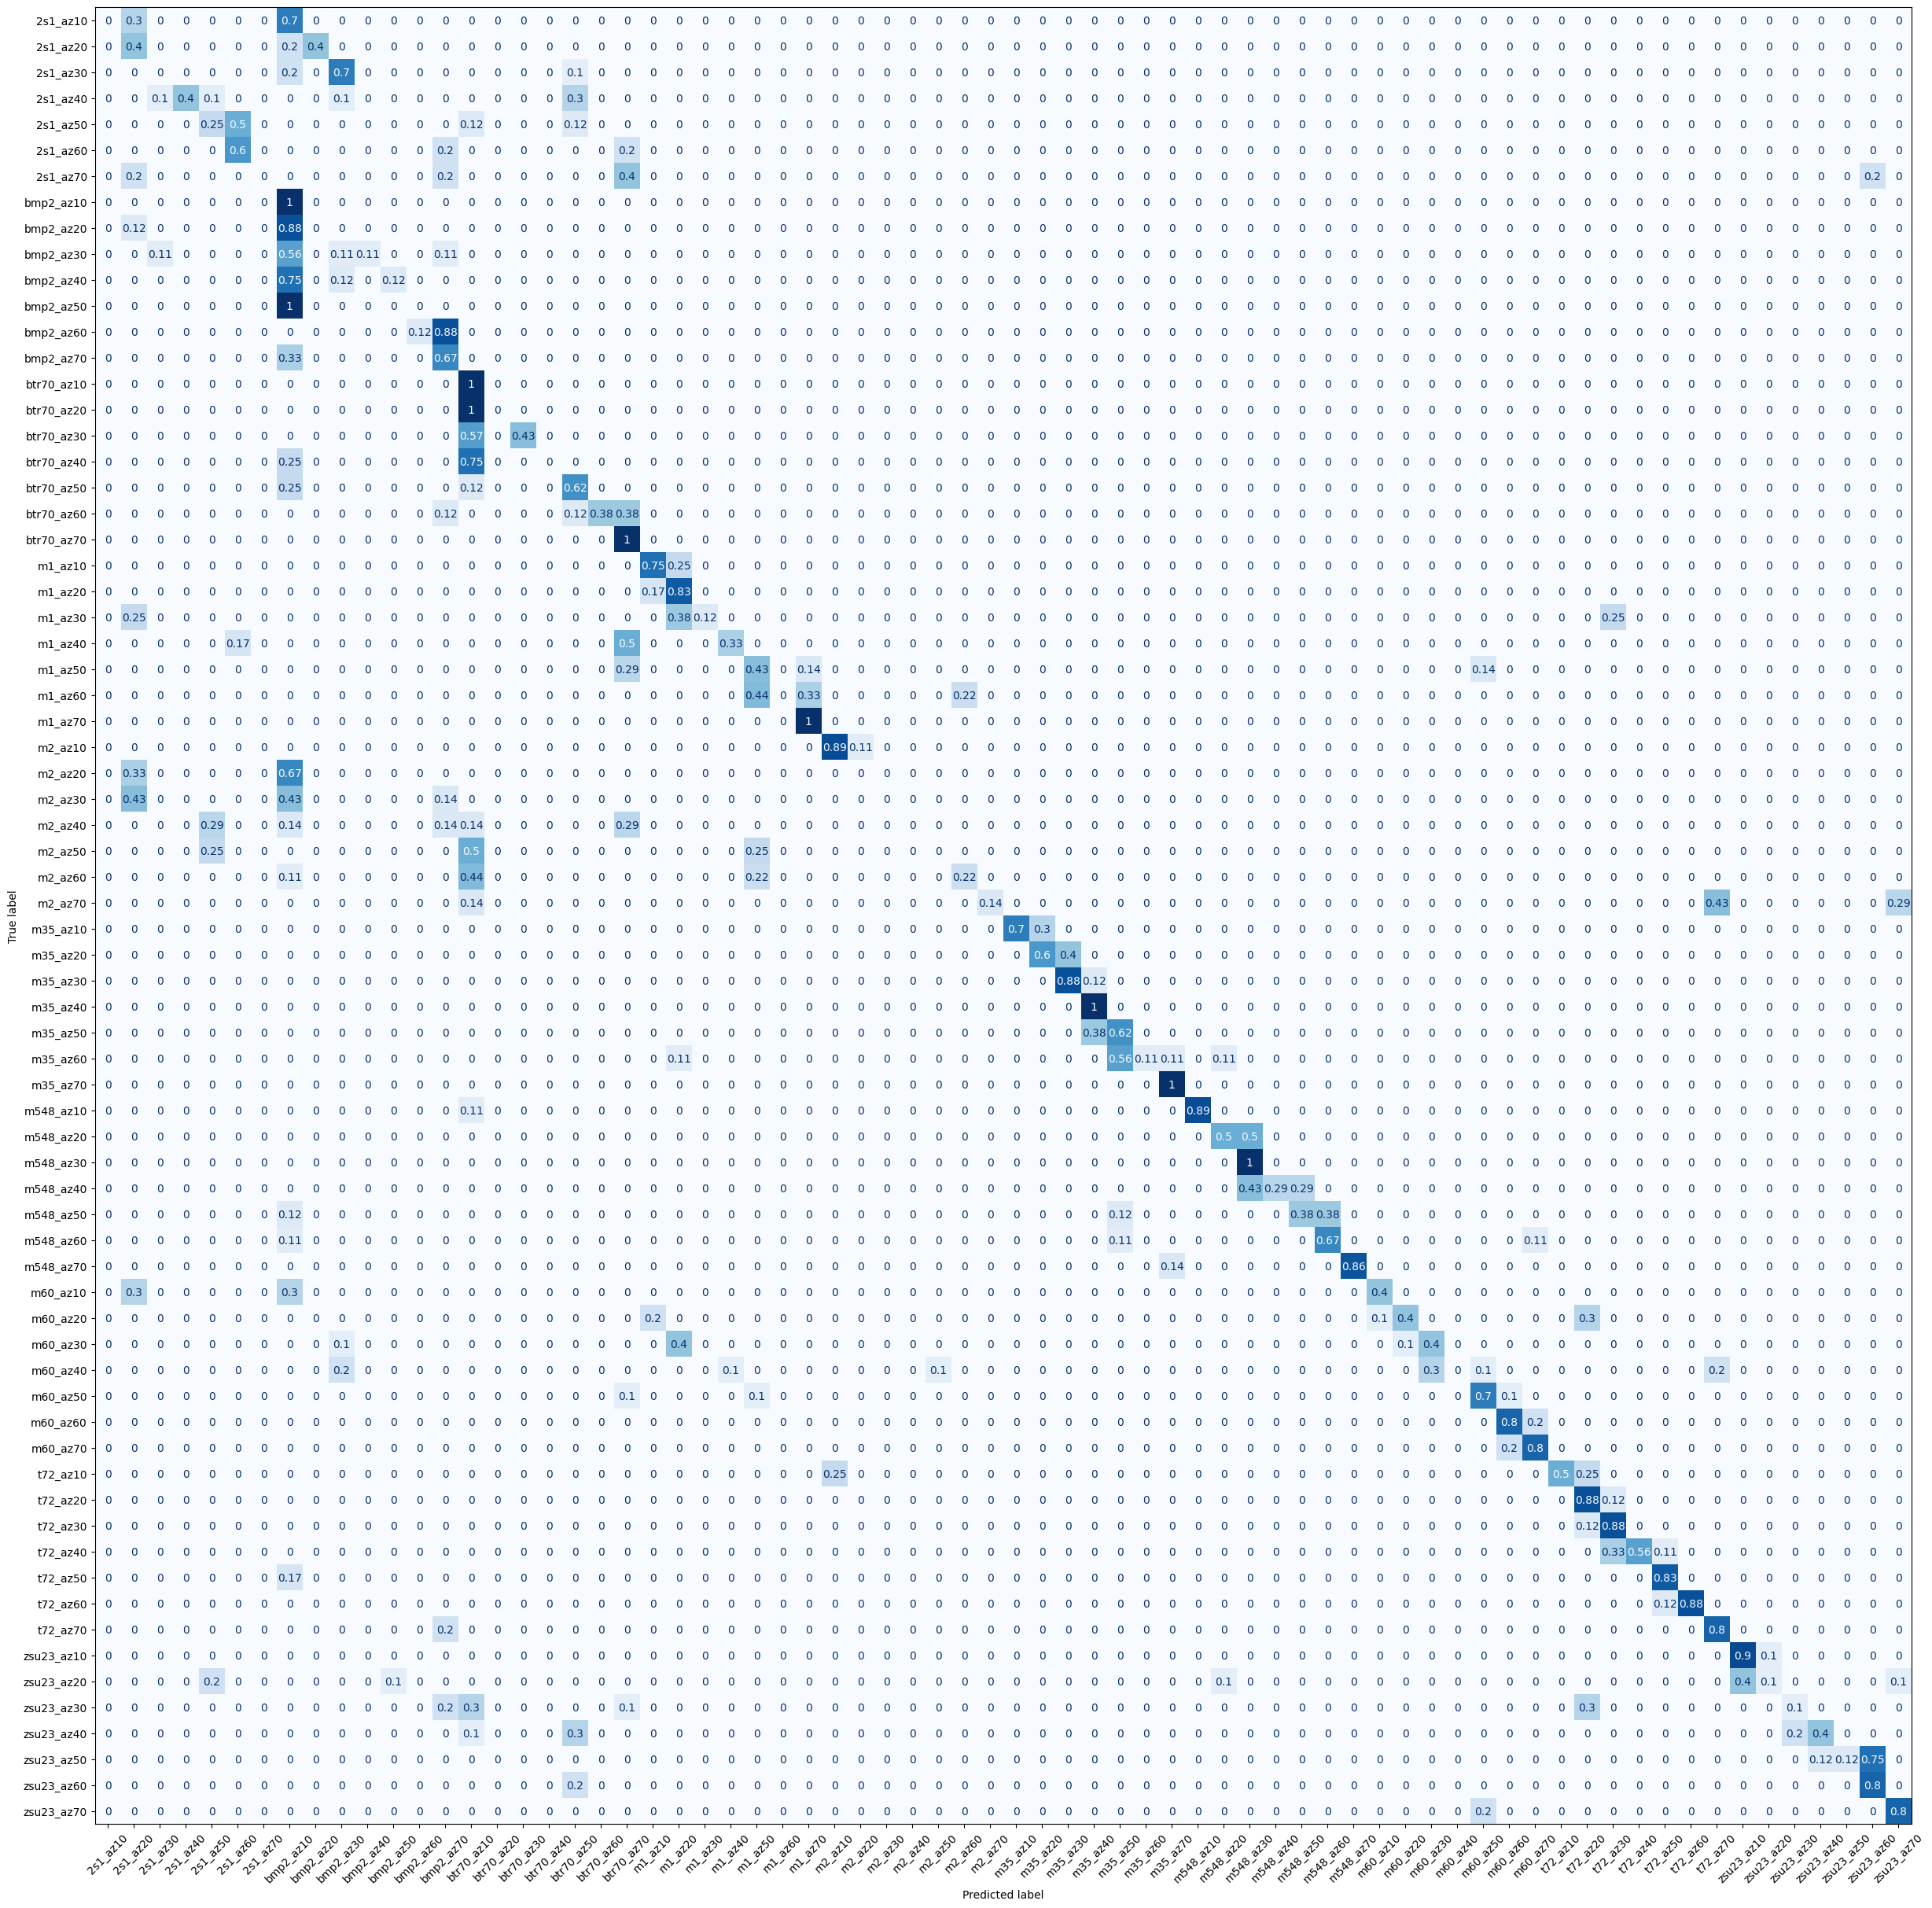

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.classes))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed123_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(30, 30))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(30, 30))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

In [17]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.classes))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    labels_lst, preds_lst = [], []
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)

            labels_lst.append(labels)
            preds_lst.append(preds)

    _labels_all = torch.cat(labels_lst).cpu().numpy()
    _preds_all = torch.cat(preds_lst).cpu().numpy()

    _old_class_labels = np.array([new_to_old_classes[_labels_all[i]] for i in range(len(_labels_all))])
    _old_class_preds = np.array([new_to_old_classes[_preds_all[i]] for i in range(len(_preds_all))])

    test_acc = (_old_class_labels == _old_class_preds).mean()
    print(f"Test Accuracy: {test_acc*100:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Accuracy: 70.5009
Evaluating Run 1 with seed 42
Test Accuracy: 78.6642
Evaluating Run 2 with seed 100
Test Accuracy: 73.0983
Evaluating Run 3 with seed 123
Test Accuracy: 71.7996
Evaluating Run 4 with seed 666
Test Accuracy: 70.3154
Evaluating Run 5 with seed 777
Test Accuracy: 69.3878
Evaluating Run 6 with seed 849
Test Accuracy: 69.3878
Evaluating Run 7 with seed 1000
Test Accuracy: 70.6865
Evaluating Run 8 with seed 1111
Test Accuracy: 71.9852
Evaluating Run 9 with seed 1234
Test Accuracy: 78.8497
Min: 69.3878
Max: 78.8497
Avg, Std: 72.4675, 3.3294


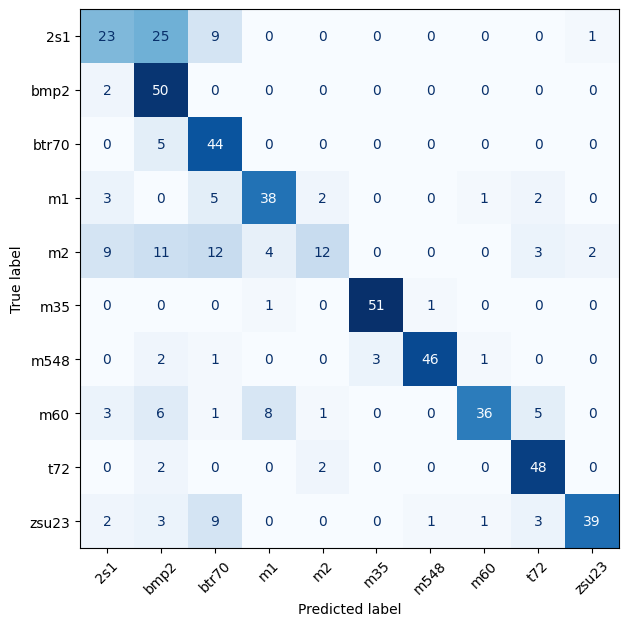

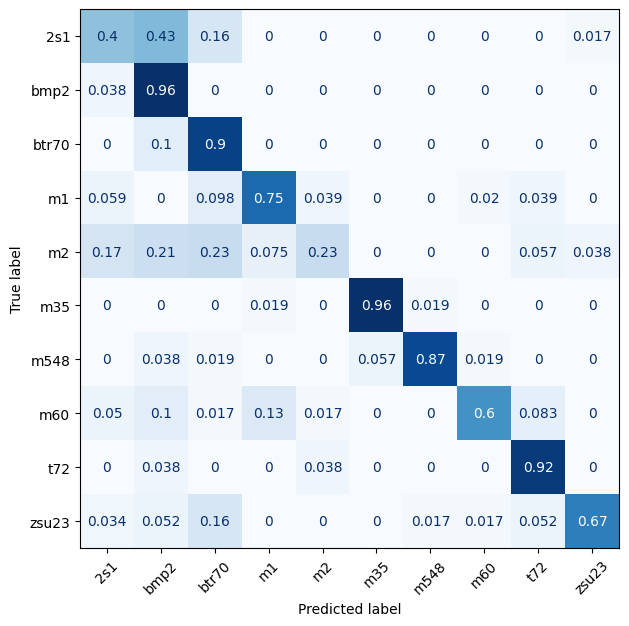

In [82]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.classes))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed123_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

_old_class_labels = np.array([new_to_old_classes[_labels_all[i]] for i in range(len(_labels_all))])
_old_class_preds = np.array([new_to_old_classes[_preds_all[i]] for i in range(len(_preds_all))])

# confusion matrix
cm = confusion_matrix(_old_class_labels, _old_class_preds)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.dataset.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_old_class_labels, _old_class_preds, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.dataset.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()
plt.show()

In [10]:
combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

In [11]:
def make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle, start_lightness=0.3):
    """
    For each vehicle, interpolate from a light tint to the tab10 base colour.
    Returns a flat list of (R,G,B) colours indexed by new_label (bin index).
    """
    tab10 = cm.get_cmap("tab10")
    bin_colors = []
    
    for v in range(n_vehicles):
        base = np.array(tab10(v)[:3])  # RGB of tab10 colour for vehicle v
        white = np.ones(3)
        # linspace from near-white to full colour, n_bins steps
        # start at start_lightness (not pure white) so first bin is still visible
        alphas = np.linspace(start_lightness, 1.0, n_bins_per_vehicle)
        for a in alphas:
            color = (1 - a) * white + a * base
            bin_colors.append(tuple(color))
    
    return bin_colors

/tmp/ipykernel_11429/4132748479.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap("tab10")
/tmp/ipykernel_11429/676779383.py:66: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/tmp/ipykernel_11429/676779383.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap("tab10")


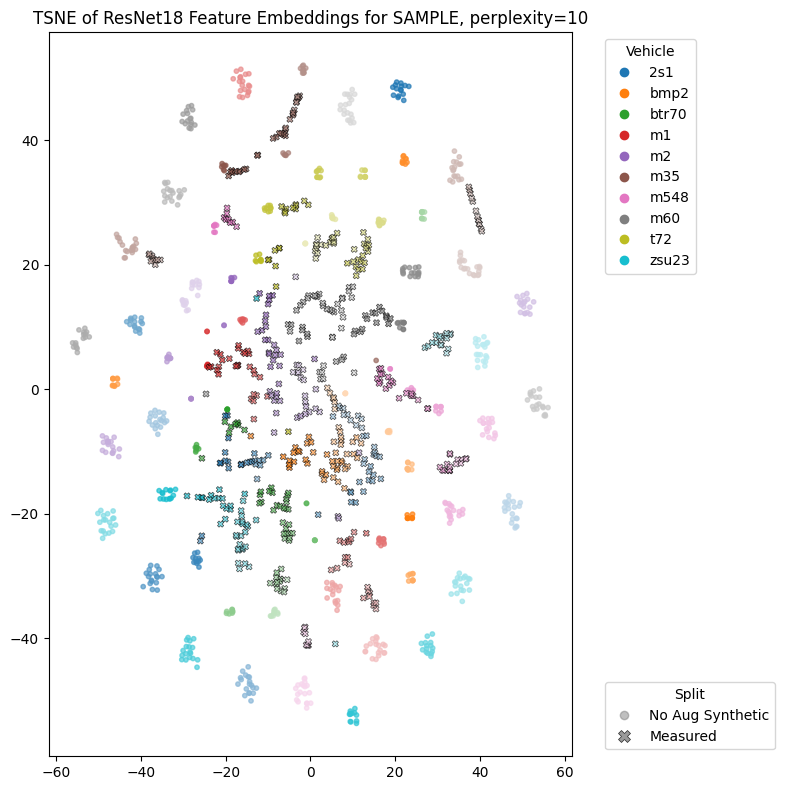

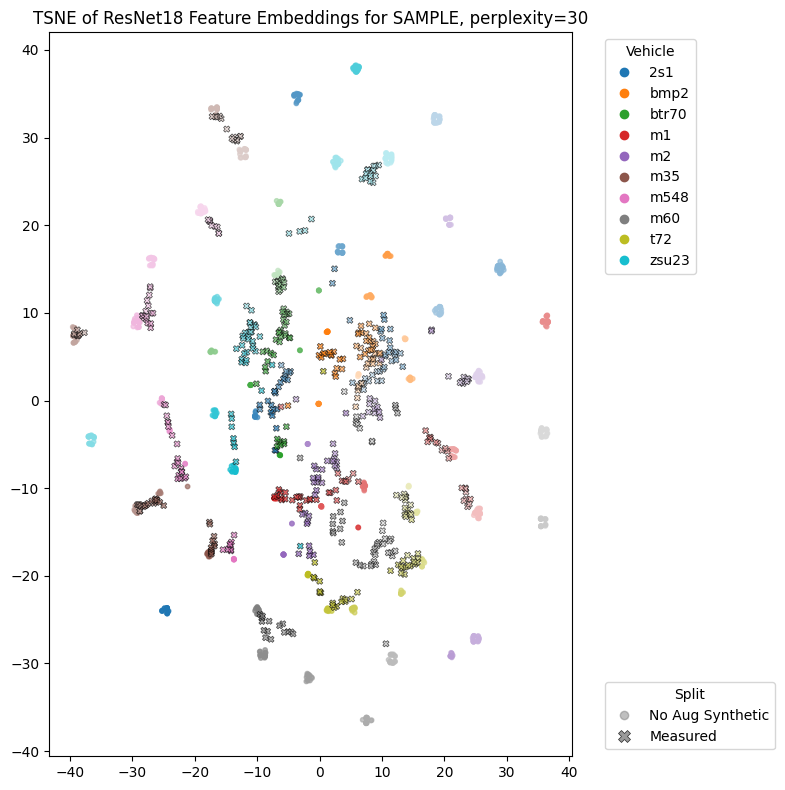

[2026-06-19 20:07:04.144] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


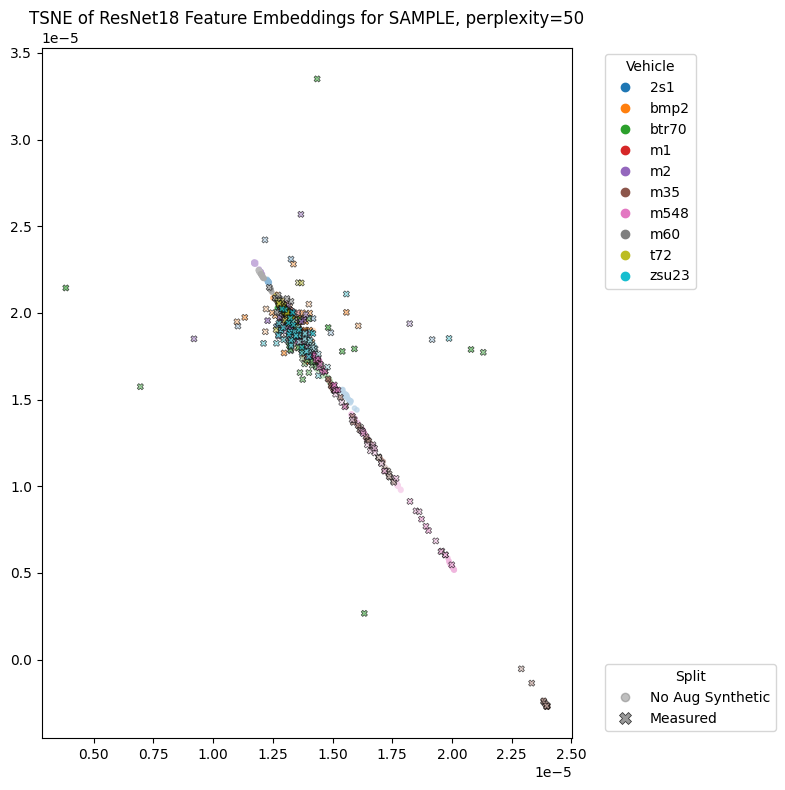

[2026-06-19 20:07:07.001] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-06-19 20:07:07.001] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


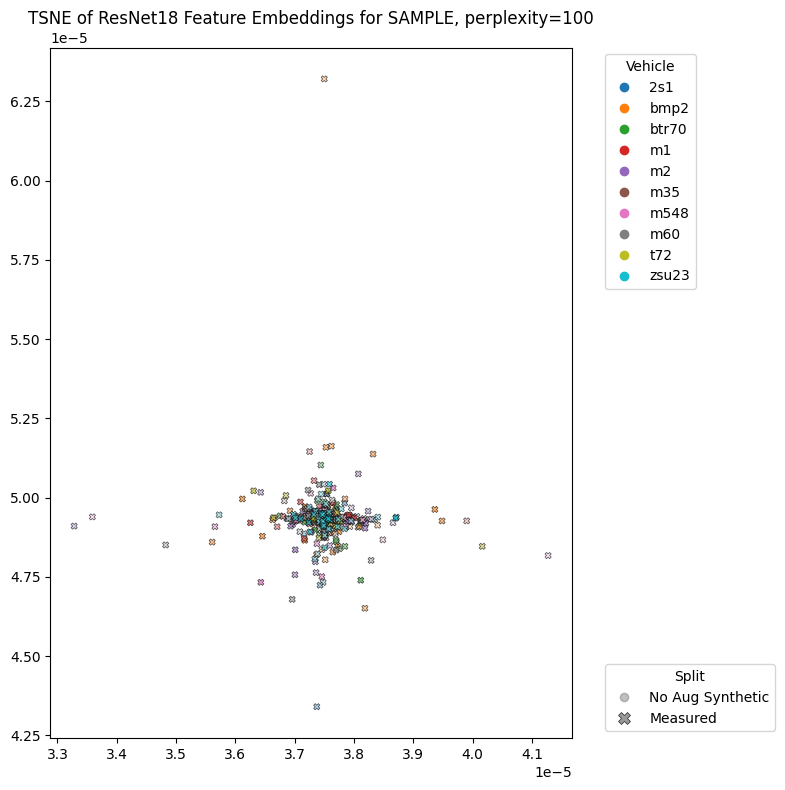

In [12]:
for num in [10, 30, 50, 100]:

    device = torch.device("cuda:0")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(train_ds.classes))
        )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed123_b16.pth"),
        map_location=device
    ))

    new_model = new_model.to(device)
    new_model.eval()

    feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    features, labels_list = [], []

    with torch.no_grad():
        for inputs, targets in combined_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            features.append(feats.cpu())
            labels_list.append(targets)

    features = torch.cat(features).numpy()
    labels_list = torch.cat(labels_list).numpy()

    tsne = TSNE(
        n_components=2,
        perplexity=num,
        learning_rate_method="adaptive",
        metric = "cosine"
    )

    features_2d = tsne.fit_transform(features)

    n_vehicles = len(train_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(labels_list[:len(train_ds)], bin_colors)
    test_colors  = labels_to_colors(labels_list[len(train_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d[:len(train_ds), 0],
        features_2d[:len(train_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d[len(train_ds):, 0],
        features_2d[len(train_ds):, 1],
        c=test_colors,
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = cm.get_cmap("tab10")
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"TSNE of ResNet18 Feature Embeddings for SAMPLE, perplexity={num}")
    plt.tight_layout()
    plt.show()

[2026-06-19 20:07:09.472] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


/tmp/ipykernel_11429/4132748479.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap("tab10")
/tmp/ipykernel_11429/2417724003.py:66: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/tmp/ipykernel_11429/2417724003.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap("tab10")


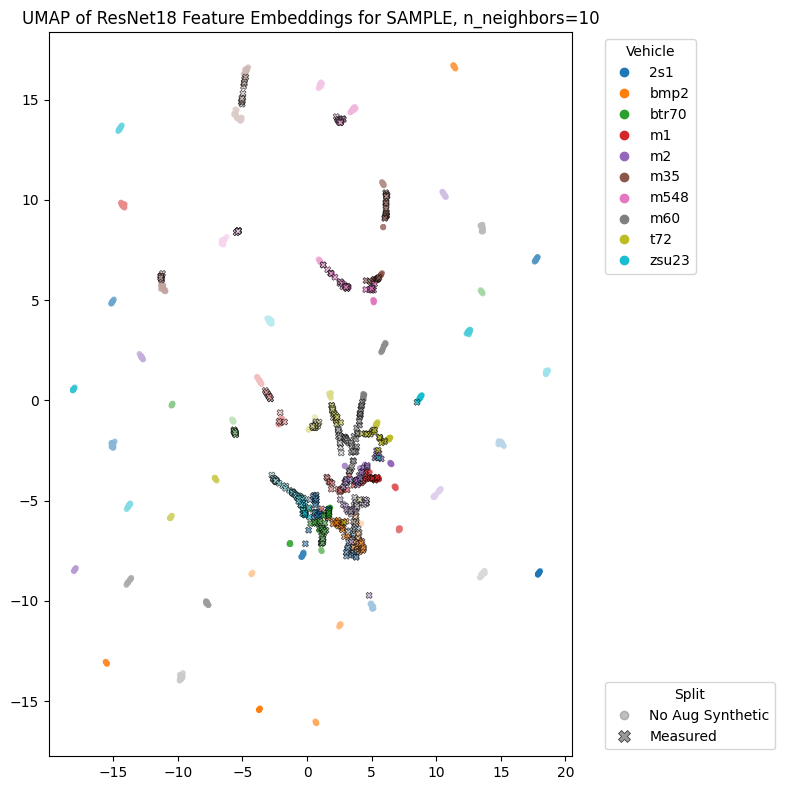

[2026-06-19 20:07:12.803] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


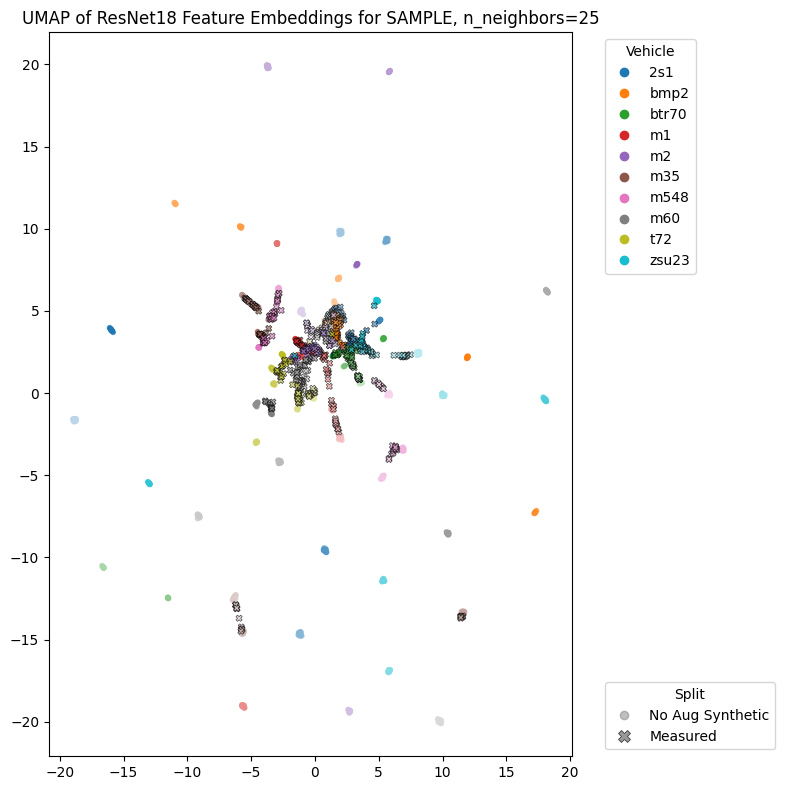

[2026-06-19 20:07:15.532] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


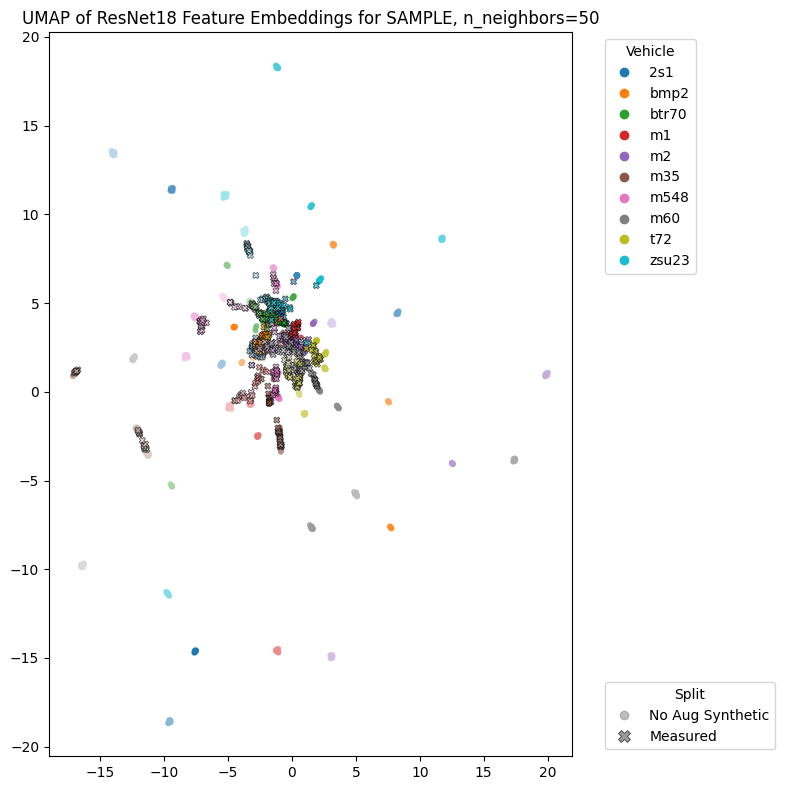

[2026-06-19 20:07:25.586] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


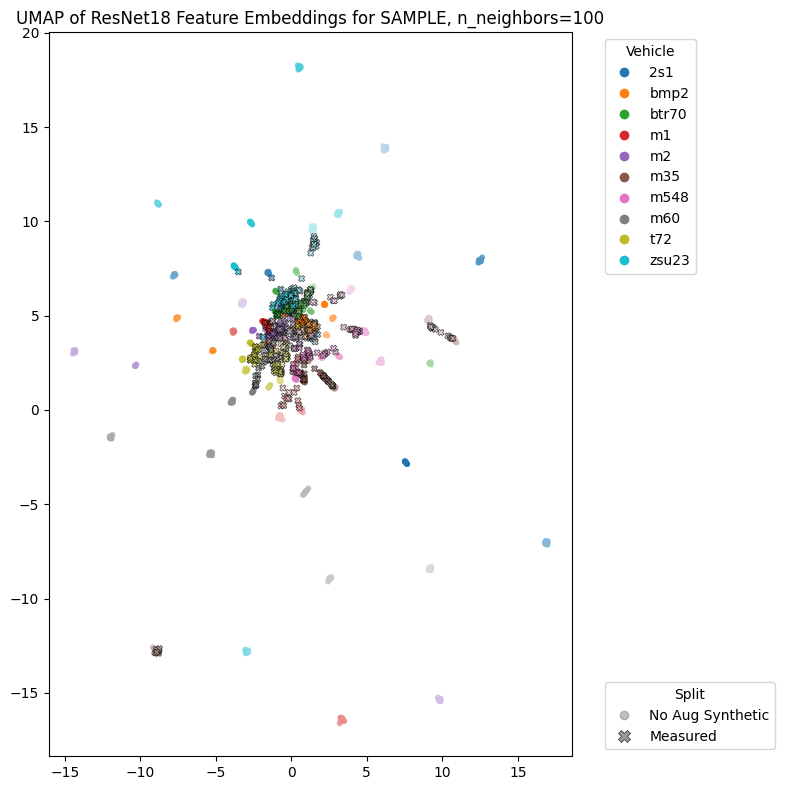

In [13]:
for num in [10, 25, 50, 100]:

    device = torch.device("cuda:0")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(train_ds.classes))
        )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed123_b16.pth"),
        map_location=device
    ))

    new_model = new_model.to(device)
    new_model.eval()

    feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    features, labels_list = [], []

    with torch.no_grad():
        for inputs, targets in combined_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            features.append(feats.cpu())
            labels_list.append(targets)

    features = torch.cat(features).numpy()
    labels_list = torch.cat(labels_list).numpy()

    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(features)

    n_vehicles = len(train_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(labels_list[:len(train_ds)], bin_colors)
    test_colors  = labels_to_colors(labels_list[len(train_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_ds), 0],
        features_2d_umap[:len(train_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(train_ds):, 0],
        features_2d_umap[len(train_ds):, 1],
        c=test_colors,
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = cm.get_cmap("tab10")
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [104]:
device = torch.device("cuda:0")
seed_lst = [123]
for i, seed in enumerate(seed_lst):
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.classes))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    synth_features, synth_labels, _ = _get_features_and_preds_from_model(model, train_ds, device, seed)
    meas_features, meas_labels, meas_preds = _get_features_and_preds_from_model(model, test_ds, device, seed)

    old_synth_labels = cp.array([new_to_old_classes[synth_labels[i].item()] for i in range(len(synth_labels))])
    old_meas_labels = cp.array([new_to_old_classes[meas_labels[i].item()] for i in range(len(meas_labels))])
    old_meas_preds = cp.array([new_to_old_classes[meas_preds[i].item()] for i in range(len(meas_preds))])

In [111]:
cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(
    meas_features, old_meas_labels, synth_features, old_synth_labels, metric = "cosine"
)

In [123]:
cosine_n_true_class

array([[ 78,  14,  79,  18,  11],
       [ 78,  14,  18,  79,  11],
       [ 38,  78, 104,  45,  46],
       ...,
       [802, 803, 752, 751, 753],
       [749, 750, 802, 752, 755],
       [802, 752, 755, 804, 749]], shape=(539, 5))

Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.435  0.696  0.870  (n=23)
bmp2        0.340  0.540  0.620  (n=50)
btr70       0.432  0.591  0.614  (n=44)
m1          0.632  0.789  0.895  (n=38)
m2          0.583  0.917  1.000  (n=12)
m35         0.549  0.882  0.980  (n=51)
m548        0.696  0.913  1.000  (n=46)
m60         0.722  0.806  0.917  (n=36)
t72         0.750  0.917  0.958  (n=48)
zsu23       0.513  0.667  0.795  (n=39)
----------------------------
Overall     0.566  0.765  0.853  (n=387)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         10.000  16.000  20.000  (n=23)
bmp2        17.000  27.000  31.000  (n=50)
btr70       19.000  26.000  27.000  (n=44)
m1          24.000  30.000  34.000  (n=38)
m2          7.000  11.000  12.000  (n=12)
m35         28.000  45.000  50.000  (n=51)
m548        32.000  42.000  46.000  (n=46)
m60         26.000  29.000  33.000  (n=36)
t72         36.000  44.000  46.000  (n=48)
zsu23       20.000  26.000  

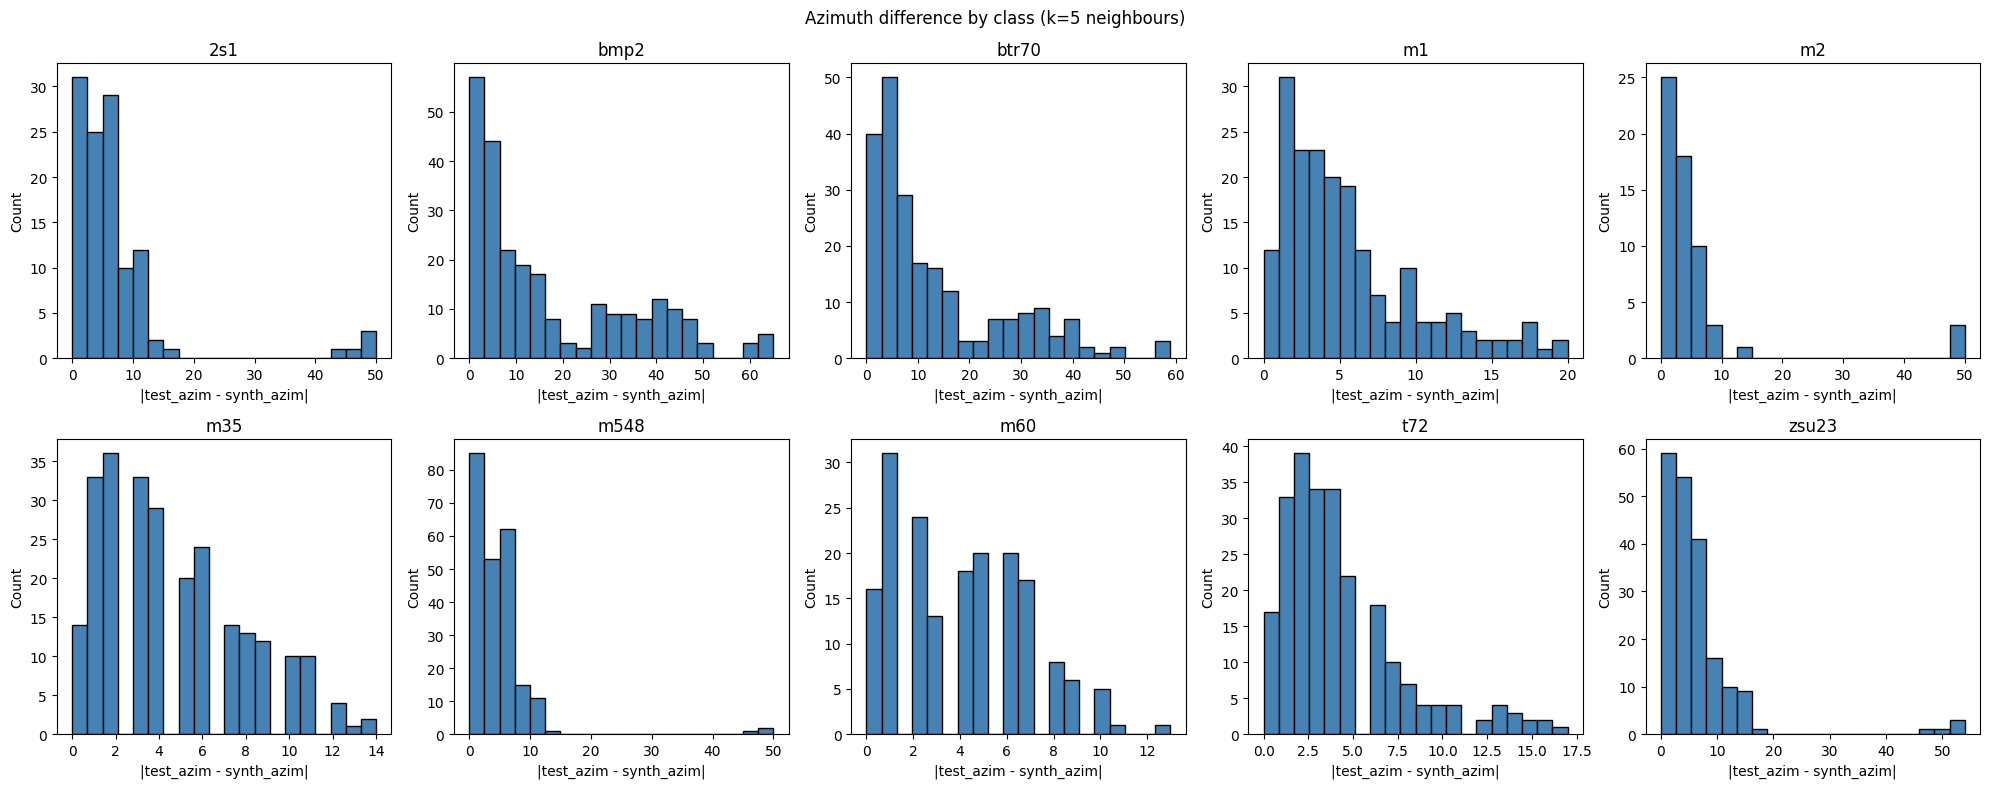

In [121]:
results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds.dataset, old_meas_labels, old_meas_preds,
    train_ds.dataset, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds.dataset, old_meas_labels, old_meas_preds,
    train_ds.dataset, cosine_n_true_class,
    q_values=[1, 3, 5], k = 5, normalise = False
)

results, azim_diffs = cp.asnumpy(results), cp.asnumpy(azim_diffs)

correct_mask    = cp.asnumpy(old_meas_preds) == cp.asnumpy(old_meas_labels)
correct_classes = cp.asnumpy(old_meas_labels)[np.where(correct_mask)[0]]
plot_azim_diffs_by_class(test_ds.dataset, azim_diffs, correct_classes)